# Surface currents in the Kiel Bight

CMEMS Baltic physics analysis (cmems_mod_bal_phy_anfc_PT1H-i), same
7-day period as the Stokes drift notebook. Surface (depth=0) Eulerian
currents for comparison.

In [1]:
import copernicusmarine as cm
import matplotlib.pyplot as plt
import numpy as np

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds_full = cm.open_dataset(
    dataset_id="cmems_mod_bal_phy_anfc_PT1H-i",
    service="arco-geo-series",
)

ds = ds_full.sel(
    longitude=slice(9.5, 11.5),
    latitude=slice(54.0, 55.5),
    time=slice("2023-04-24", "2023-05-01"),
).sel(depth=0, method="nearest")[["uo", "vo"]].load()

ds = ds.assign_coords(
    longitude=np.linspace(float(ds.longitude[0]), float(ds.longitude[-1]), len(ds.longitude)),
    latitude=np.linspace(float(ds.latitude[0]), float(ds.latitude[-1]), len(ds.latitude)),
)

ds["speed"] = np.sqrt(ds["uo"]**2 + ds["vo"]**2)
ds

INFO - 2026-03-25T09:05:10Z - Selected dataset version: "202411"


INFO - 2026-03-25T09:05:10Z - Selected dataset part: "default"


WARNING - 2026-03-25T09:05:10Z - The dataset cmems_mod_bal_phy_anfc_PT1H-i, version '202411', part 'default' is currently being updated. Data after 2026-03-25T00:00:00.000Z may not be up to date.


<xarray.Dataset> Size: 15MB
Dimensions:    (time: 192, latitude: 90, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2023-04-24 ... 2023-05-01T23:00:00
  * latitude   (latitude) float64 720B 54.01 54.02 54.04 ... 55.46 55.47 55.49
  * longitude  (longitude) float64 576B 9.514 9.542 9.569 ... 11.43 11.46 11.49
    depth      float32 4B 0.5016
Data variables:
    uo         (time, latitude, longitude) float32 5MB nan nan nan ... nan nan
    vo         (time, latitude, longitude) float32 5MB nan nan nan ... nan nan
    speed      (time, latitude, longitude) float32 5MB nan nan nan ... nan nan
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:11
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-12-01 01:00:00
    stop_date:                 2024-12-01 12:00:00
    title:                     CMEMS NEMO hourly model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

## Mean surface currents

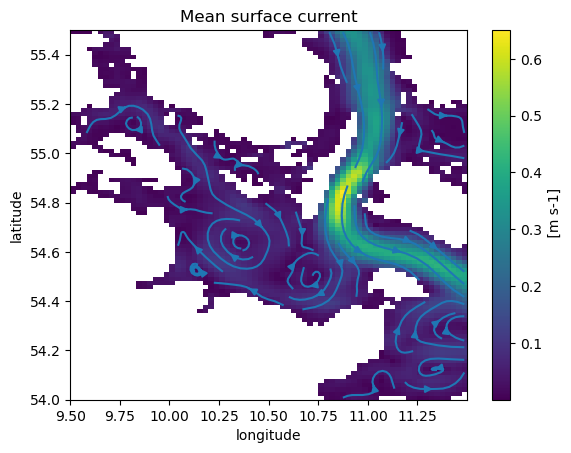

In [3]:
ds_mean = ds[["uo", "vo"]].mean("time")
np.sqrt(ds_mean["uo"]**2 + ds_mean["vo"]**2).plot()
ds_mean.plot.streamplot(x="longitude", y="latitude", u="uo", v="vo")
plt.title("Mean surface current")
plt.show()

## Max surface current speed

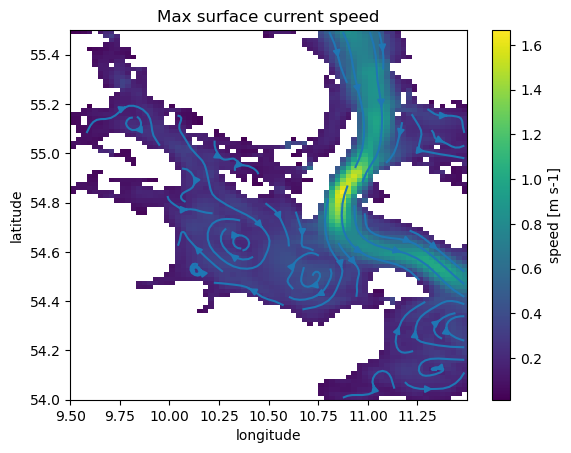

In [4]:
ds["speed"].max("time").plot()
ds_mean.plot.streamplot(x="longitude", y="latitude", u="uo", v="vo")
plt.title("Max surface current speed")
plt.show()

## RMS surface current speed

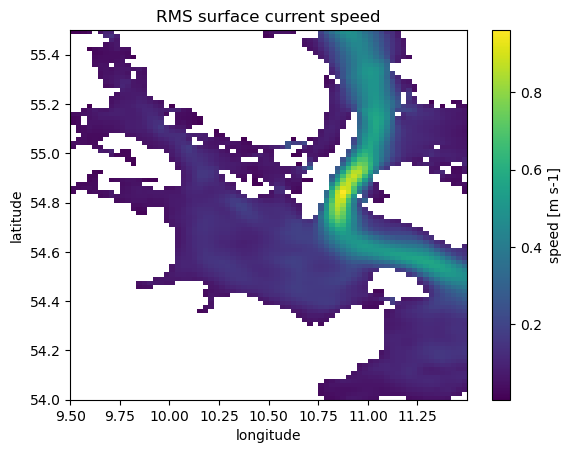

In [5]:
np.sqrt((ds["speed"]**2).mean("time")).plot()
plt.title("RMS surface current speed")
plt.show()

## Summary

In [6]:
speed = ds["speed"]
print(f"Surface current speed (depth=0):")
print(f"  Mean: {float(speed.mean()):.4f} m/s")
print(f"  RMS:  {float(np.sqrt((speed**2).mean())):.4f} m/s")
print(f"  Max:  {float(speed.max()):.4f} m/s")
print(f"  P95:  {float(speed.quantile(0.95)):.4f} m/s")

Surface current speed (depth=0):
  Mean: 0.1504 m/s
  RMS:  0.2323 m/s
  Max:  1.6660 m/s
  P95:  0.5473 m/s
